In [3]:

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
import pandas as pd
import random
import time

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120

In [4]:
TRAIN_DIR = "archive/asl_alphabet_train/asl_alphabet_train"  
TEST_DIR = "archive/asl_alphabet_test/asl_alphabet_test"   

IMG_SIZE = 64
SAMPLES_PER_CLASS = 1000
RANDOM_SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 25
LEARNING_RATE = 0.001

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

In [5]:

def load_data(data_dir, img_size, samples_per_class):
    classes = sorted(os.listdir(data_dir))
    images = []
    labels = []
    
    print(f"Loading data: {len(classes)} classes, {samples_per_class} samples each...")
    
    for cls in classes:
        cls_path = os.path.join(data_dir, cls)
        if not os.path.isdir(cls_path):
            continue
        all_files = os.listdir(cls_path)
        sampled_files = random.sample(all_files, min(samples_per_class, len(all_files)))
        for fname in sampled_files:
            img = Image.open(os.path.join(cls_path, fname)).resize((img_size, img_size)).convert("L")
            images.append(np.array(img).flatten())
            labels.append(cls)
    
    X = np.array(images, dtype=np.float32)
    y = np.array(labels)
    print(f"Loaded {X.shape[0]} images, each with {X.shape[1]} features")
    return X, y, classes

X, y, class_names = load_data(TRAIN_DIR, IMG_SIZE, SAMPLES_PER_CLASS)

Loading data: 29 classes, 1000 samples each...
Loaded 29000 images, each with 4096 features


In [6]:

X = X / 255.0

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

# StandardScaler: SVM is sensitive to feature scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")

Training set: 23200 samples
Test set:     5800 samples


In [ ]:
print("  Linear SVM - Hyperparameter Tuning")

C_values = [0.01, 0.1, 1.0, 10]
linear_results = []

for c in C_values:
    print(f"\nTraining LinearSVC with C = {c} ...")
    start = time.time()
    
    model = LinearSVC(
        C=c,
        max_iter=5000,
        random_state=RANDOM_SEED,
        dual=False
    )
    model.fit(X_train_scaled, y_train)
    
    train_time = time.time() - start
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    linear_results.append({'C': c, 'Accuracy': acc, 'F1-Score': f1, 'Time (s)': round(train_time, 1)})
    print(f"  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  Time: {train_time:.1f}s")

linear_df = pd.DataFrame(linear_results)
print("\nLinear SVM Results:")
print(linear_df.to_string(index=False))

best_linear = linear_df.loc[linear_df['Accuracy'].idxmax()]
best_linear_c = best_linear['C']
print(f"\nBest Linear SVM: C = {best_linear_c} (Accuracy: {best_linear['Accuracy']:.4f})")

  Linear SVM - Hyperparameter Tuning

Training LinearSVC with C = 0.01 ...
  Accuracy: 0.7338  |  F1: 0.7335  |  Time: 747.0s

Training LinearSVC with C = 0.1 ...
  Accuracy: 0.7422  |  F1: 0.7420  |  Time: 2281.5s

Training LinearSVC with C = 1.0 ...
  Accuracy: 0.7216  |  F1: 0.7210  |  Time: 15228.8s

Training LinearSVC with C = 10 ...


In [7]:
linear_results = [
    {'C': 0.01, 'Accuracy': 0.7338, 'F1-Score': 0.7335, 'Time (s)': 747.0},
    {'C': 0.1,  'Accuracy': 0.7422, 'F1-Score': 0.7420, 'Time (s)': 2281.5},
    {'C': 1.0,  'Accuracy': 0.7216, 'F1-Score': 0.7210, 'Time (s)': 15228.8},
]

linear_df = pd.DataFrame(linear_results)
print("Linear SVM Results:")
print(linear_df.to_string(index=False))
print(f"\nBest Linear SVM: C = 0.1 (Accuracy: 0.7422)")

Linear SVM Results:
   C  Accuracy  F1-Score  Time (s)
0.01    0.7338    0.7335     747.0
0.10    0.7422    0.7420    2281.5
1.00    0.7216    0.7210   15228.8

Best Linear SVM: C = 0.1 (Accuracy: 0.7422)


In [8]:

best_svm = LinearSVC(C=0.1, max_iter=5000, random_state=RANDOM_SEED, dual=False)
best_svm.fit(X_train_scaled, y_train)
y_pred_best = best_svm.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')


print("   Best SVM (Linear, C=0.1) - Results")

print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f}")
print(f"   Recall:    {recall:.4f}")
print(f"   F1-Score:  {f1:.4f}")


   Best SVM (Linear, C=0.1) - Results
   Accuracy:  0.7422 (74.22%)
   Precision: 0.7441
   Recall:    0.7422
   F1-Score:  0.7420


In [9]:

print("\nPer-Class Classification Report:\n")
print(classification_report(y_test, y_pred_best, target_names=class_names))


Per-Class Classification Report:

              precision    recall  f1-score   support

           A       0.67      0.78      0.72       200
           B       0.69      0.71      0.70       200
           C       0.84      0.70      0.76       200
           D       0.69      0.73      0.71       200
           E       0.70      0.69      0.70       200
           F       0.76      0.61      0.68       200
           G       0.76      0.77      0.76       200
           H       0.72      0.81      0.76       200
           I       0.81      0.80      0.81       200
           J       0.77      0.79      0.78       200
           K       0.77      0.73      0.75       200
           L       0.85      0.80      0.82       200
           M       0.74      0.72      0.73       200
           N       0.81      0.76      0.78       200
           O       0.74      0.73      0.74       200
           P       0.86      0.80      0.83       200
           Q       0.82      0.86      0.84   

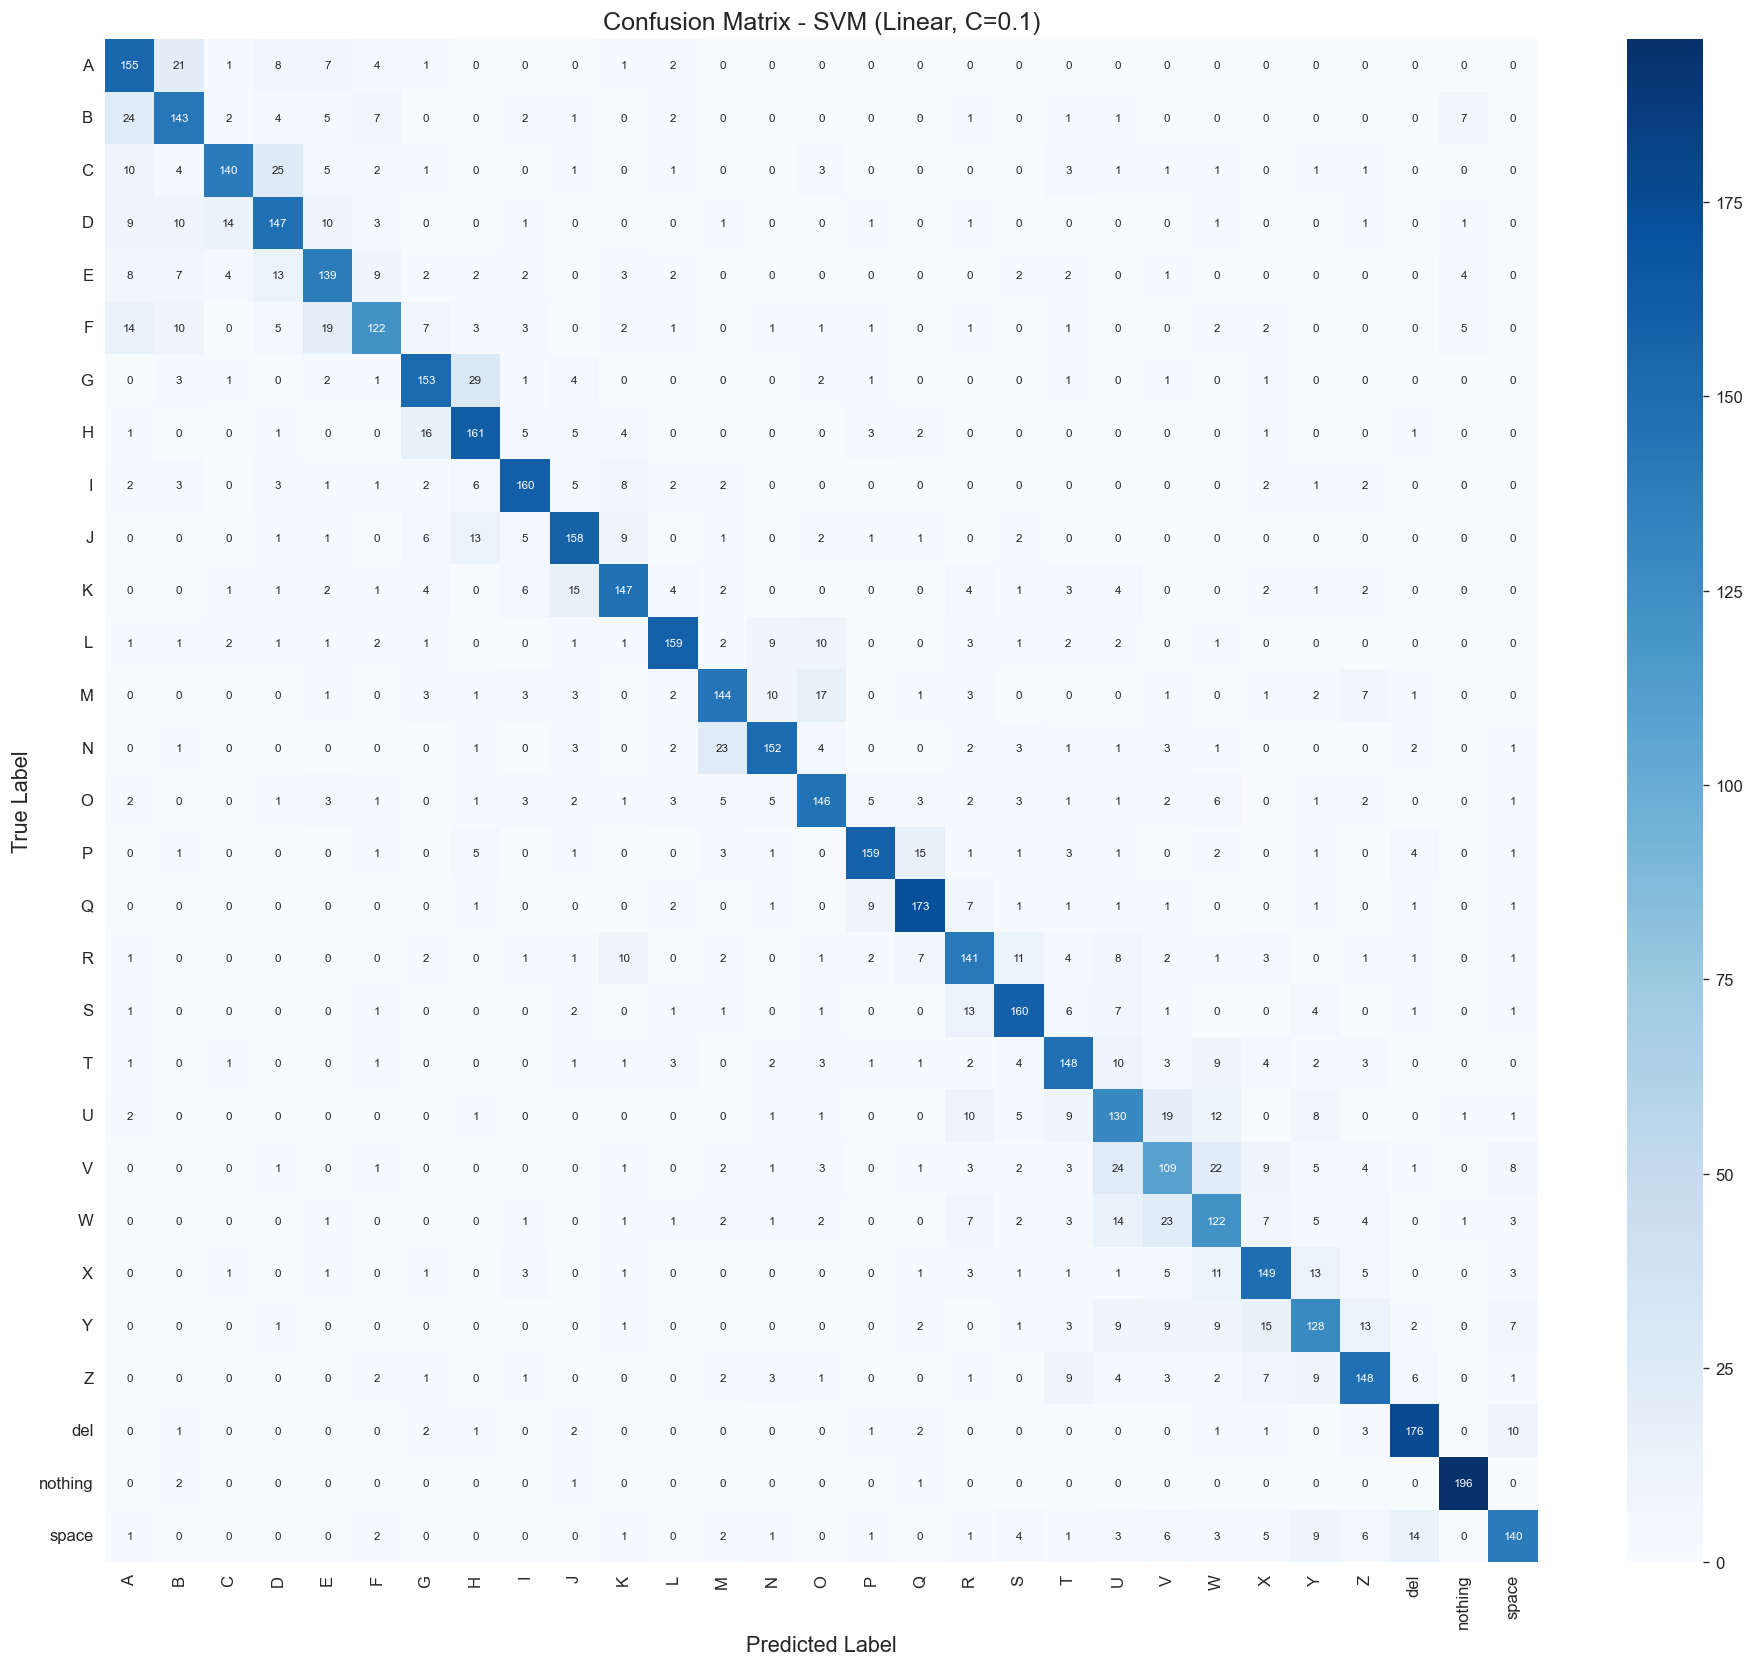

In [10]:
cm = confusion_matrix(y_test, y_pred_best, labels=class_names)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            ax=ax, annot_kws={"size": 7})
ax.set_xlabel("Predicted Label", fontsize=13)
ax.set_ylabel("True Label", fontsize=13)
ax.set_title("Confusion Matrix - SVM (Linear, C=0.1)", fontsize=15)
plt.tight_layout()
plt.savefig("confusion_matrix_svm.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:

confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((class_names[i], class_names[j], cm[i][j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 10 Most Confused Class Pairs:")
print("-" * 40)
for true_cls, pred_cls, count in confusion_pairs[:10]:
    print(f"  True: {true_cls:>8s}  ->  Predicted: {pred_cls:>8s}  |  Count: {count}")

Top 10 Most Confused Class Pairs:
----------------------------------------
  True:        G  ->  Predicted:        H  |  Count: 29
  True:        C  ->  Predicted:        D  |  Count: 25
  True:        B  ->  Predicted:        A  |  Count: 24
  True:        V  ->  Predicted:        U  |  Count: 24
  True:        N  ->  Predicted:        M  |  Count: 23
  True:        W  ->  Predicted:        V  |  Count: 23
  True:        V  ->  Predicted:        W  |  Count: 22
  True:        A  ->  Predicted:        B  |  Count: 21
  True:        F  ->  Predicted:        E  |  Count: 19
  True:        U  ->  Predicted:        V  |  Count: 19



Total misclassified: 1495 / 5800


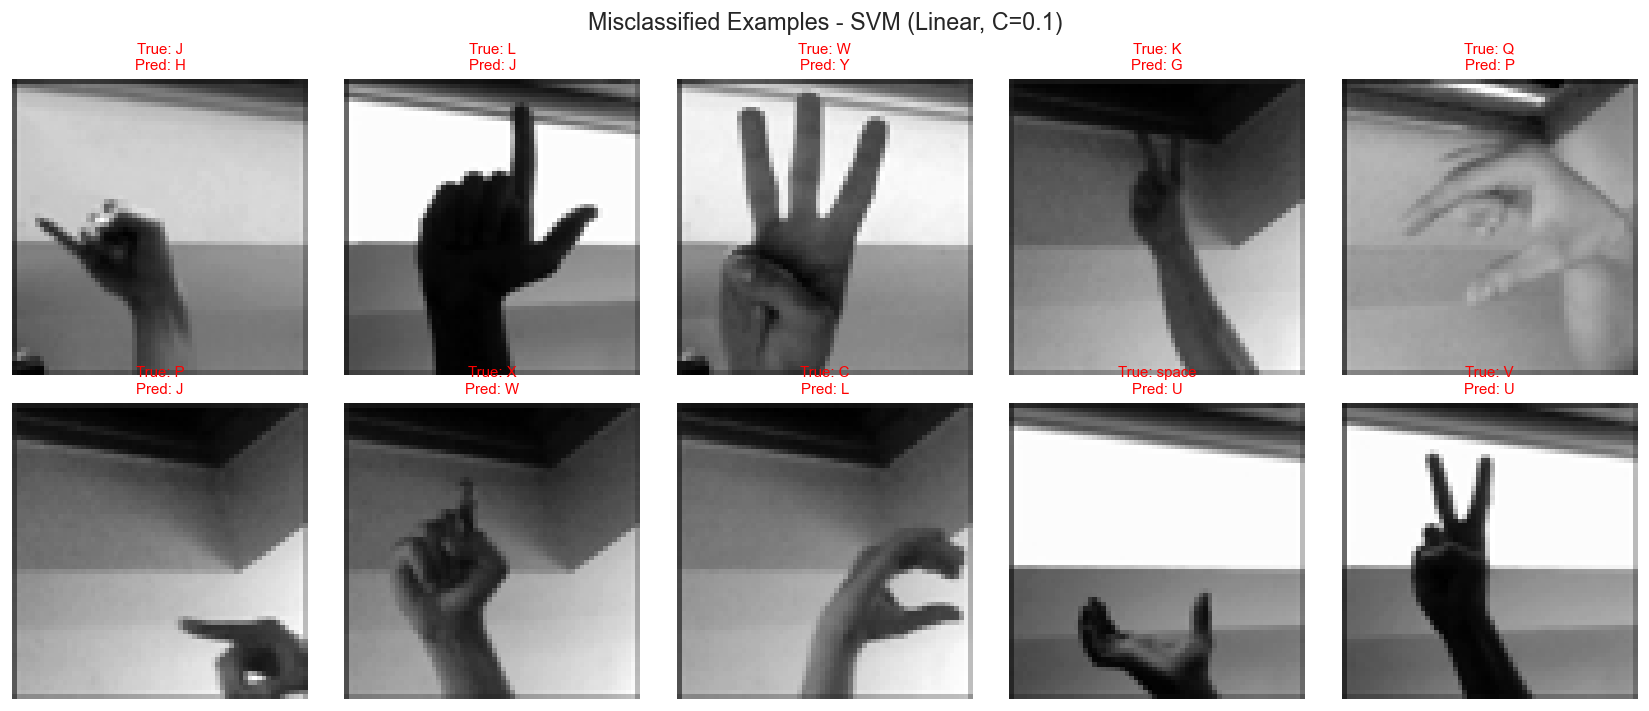

In [12]:

misclassified_idx = np.where(y_pred_best != y_test)[0]
print(f"\nTotal misclassified: {len(misclassified_idx)} / {len(y_test)}")

num_show = min(10, len(misclassified_idx))
sample_idx = random.sample(list(misclassified_idx), num_show)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()
for i, idx in enumerate(sample_idx):
    img = X_test[idx].reshape(IMG_SIZE, IMG_SIZE)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"True: {y_test[idx]}\nPred: {y_pred_best[idx]}",
                      fontsize=9, color='red')
    axes[i].axis('off')

plt.suptitle("Misclassified Examples - SVM (Linear, C=0.1)", fontsize=14)
plt.tight_layout()
plt.savefig("misclassified_svm.png", dpi=150, bbox_inches='tight')
plt.show()